# 03 - Decline-rate extraction

Extract per-participant slopes for each normed domain (`memory_z`, `attention_z`,
`language_z`) using three estimators - independent OLS, robust Theil-Sen, and a
population-pooled mixed-effects model (MixedLM) - then build additional trend
features (variability, curvature, missingness). The shrinkage plot below shows
why MixedLM matters: participants with few visits get pulled toward the
population slope, while participants with many visits stay close to their own
independent estimate.

In [1]:
import sys
sys.path.append("..")

import os
import matplotlib.pyplot as plt

from src.data_ingest import load_combined_longitudinal
from src.longitudinal.slope_extraction import extract_slopes
from src.longitudinal.trends import build_trend_features
from src.visualisation.visualisation import plot_slope_shrinkage


In [2]:
combined = load_combined_longitudinal(
    sim_path="../data/simulated/longitudinal_simulated.csv",
    sessions_path="../data/sessions/sessions_log.csv",
    participants_path="../data/sessions/participants.csv",
)
combined.shape


(1800, 9)

In [3]:
DOMAINS = ("memory_z", "attention_z", "language_z")

slope_table = extract_slopes(combined, domains=DOMAINS)
trend_table = build_trend_features(combined, domains=DOMAINS)

subject_features = slope_table.merge(trend_table, on="participant_id", how="outer")
subject_features.shape


c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 393.565982
  warnings.warn(msg, ConvergenceWarning)
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive defi

c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1620.094185
  warnings.warn(msg, ConvergenceWarning)
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(m

c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


(250, 60)

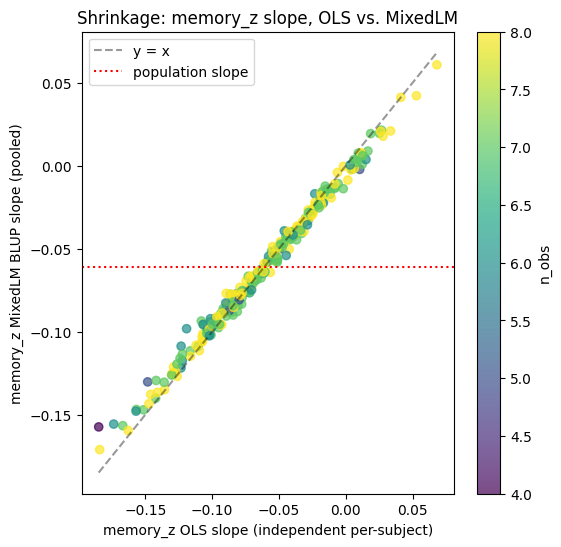

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_slope_shrinkage(slope_table, domain="memory_z", ax=ax)
plt.show()


In [5]:
os.makedirs("../data/processed", exist_ok=True)
subject_features.to_csv("../data/processed/subject_features.csv", index=False)
subject_features.head()


,participant_id,memory_z_slope_ols,memory_z_intercept_ols,memory_z_n_obs,memory_z_r2,memory_z_slope_theilsen,memory_z_intercept_theilsen,memory_z_lo,memory_z_hi,memory_z_slope_mixedlm,...,attention_z_baseline_value,attention_z_last_value,attention_z_raw_delta,attention_z_raw_delta_per_month,language_z_resid_std,language_z_curvature,language_z_baseline_value,language_z_last_value,language_z_raw_delta,language_z_raw_delta_per_month
0,P0000,-0.030054,0.236064,7,0.759691,-0.035674,0.261203,-0.047738,0.002398,-0.031574,...,0.048161,-1.148496,-1.196657,-0.028492,0.134341,-0.000099,0.144164,-0.855189,-0.999353,-0.023794
1,P0001,-0.025161,0.383992,7,0.562539,-0.021770,0.352219,-0.057536,0.008699,-0.026649,...,0.343199,0.132569,-0.210630,-0.005015,0.256341,-0.000355,0.131732,-0.249049,-0.380781,-0.009066
2,P0002,-0.062336,-0.357245,8,0.852285,-0.063285,-0.211410,-0.097895,-0.025491,-0.063531,...,-0.378259,-0.677896,-0.299637,-0.007134,0.203505,0.000135,-0.269851,-0.724438,-0.454587,-0.010823
3,P0003,0.004516,0.037487,7,0.033325,0.003836,0.001022,-0.024553,0.050425,-0.002022,...,0.818439,-0.106411,-0.924850,-0.025690,0.443727,-0.002047,0.827412,0.365059,-0.462353,-0.012843
4,P0004,-0.053051,-1.054133,8,0.832820,-0.055613,-0.865079,-0.076887,-0.021511,-0.057218,...,-0.599239,-1.115819,-0.516580,-0.012300,0.159894,0.000134,-0.897428,-0.609747,0.287681,0.006850
